In [1]:
# helps tell you what name of file image is 
import os
print(os.listdir())

['kenics_images', 'triplecoil_images', 'baseline_images', 'ezgif-437ec2efc9d719d8-jpg.zip', 'pachinko_mixing_results.csv', 'pachinko_images', 'ezgif-4da48a0cd1922b98-jpg.zip', 'image processing.ipynb', 'corkscrew_mixing_results.csv', 'corkscrew_images', 'kenics_mixing_results.csv', '.ipynb_checkpoints', 'ezgif-5575c627248acd12-jpg.zip', 'baseline_mixing_results.csv', 'triple_coil_helix_mixing_results.csv']


Folder already exists. Skipping unzip.
Found 24 images.


,Geometry,Image,Mean Intensity,Std Dev,CV,x1,x2,y1,y2
0,baseline,ezgif-frame-001.jpg,27.850979,10.729975,0.385264,260,1390,195,716
1,baseline,ezgif-frame-002.jpg,27.852112,10.959726,0.393497,260,1390,195,716
2,baseline,ezgif-frame-003.jpg,26.844764,11.046781,0.411506,260,1390,195,716
3,baseline,ezgif-frame-004.jpg,30.625290,11.625410,0.379602,260,1390,195,716
4,baseline,ezgif-frame-005.jpg,30.625813,11.431402,0.373260,260,1390,195,716
5,baseline,ezgif-frame-006.jpg,34.788001,13.063757,0.375525,260,1390,195,716
6,baseline,ezgif-frame-007.jpg,34.988883,13.038946,0.372660,260,1390,195,716
7,baseline,ezgif-frame-008.jpg,31.666297,10.719737,0.338522,260,1390,195,716
8,baseline,ezgif-frame-009.jpg,30.064838,10.138050,0.337206,260,1390,195,716
9,baseline,ezgif-frame-010.jpg,30.042527,10.064962,0.335024,260,1390,195,716



Saved results to: baseline_mixing_results.csv

Summary:
       Mean Intensity    Std Dev         CV
count       24.000000  24.000000  24.000000
mean        34.584654  11.745758   0.342409
std          4.936730   1.391378   0.035945
min         26.844764   9.387842   0.277020
25%         30.625682  10.716460   0.312946
50%         34.374208  11.533406   0.339265
75%         39.273487  12.943585   0.372810
max         46.343232  14.035663   0.411506

Average CV for baseline: 0.342
Best CV: 0.277
Worst CV: 0.412


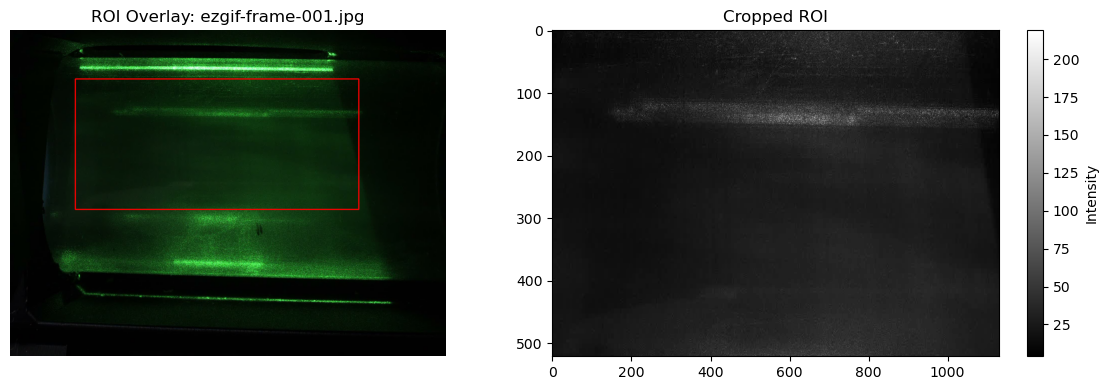

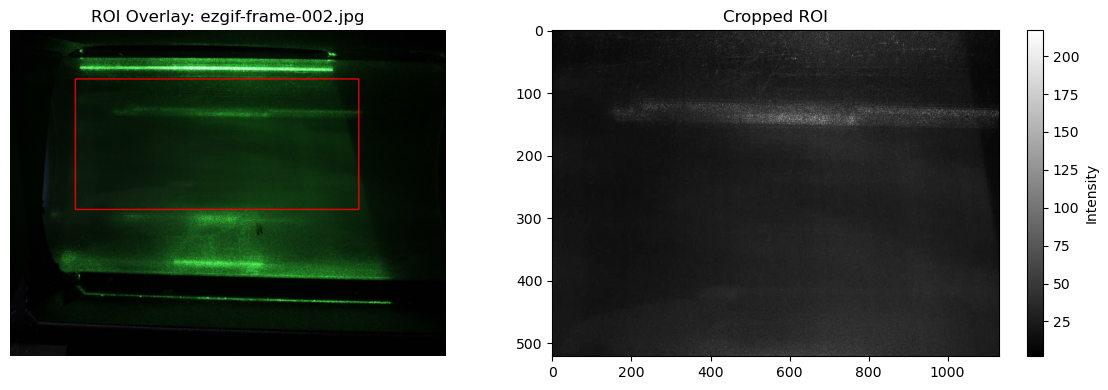

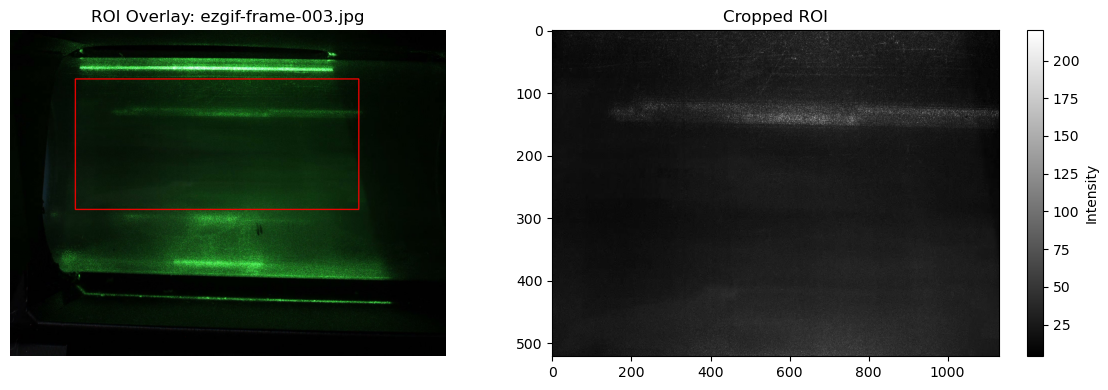

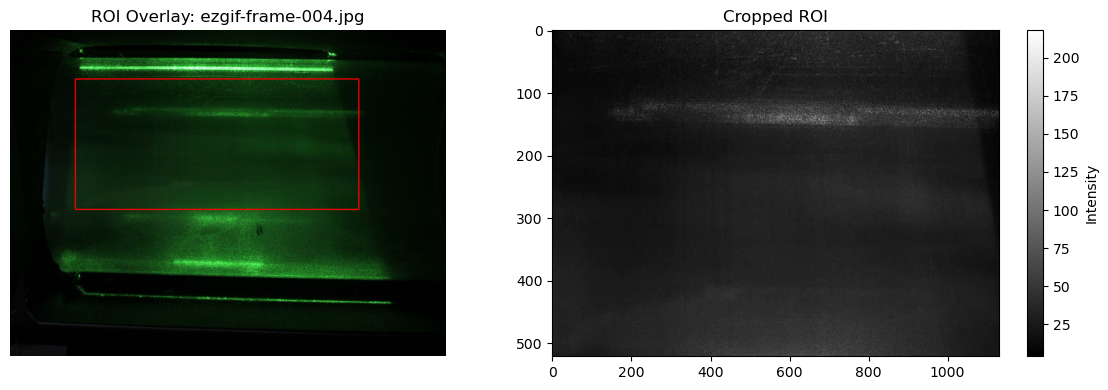

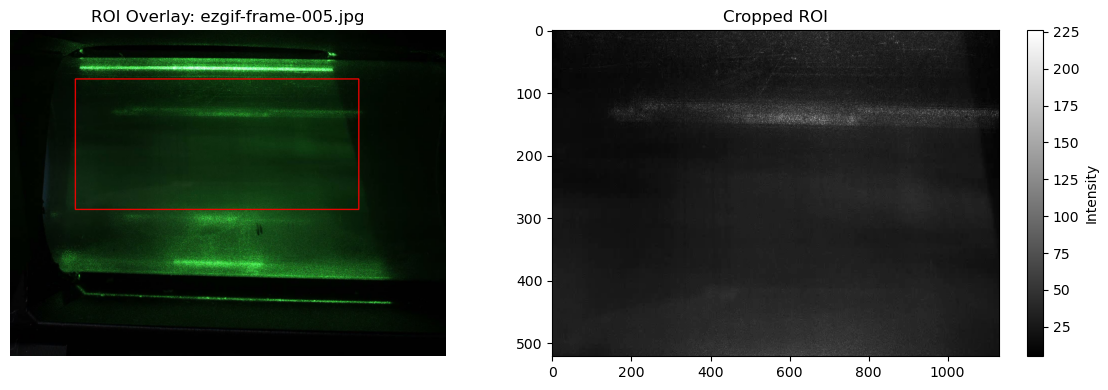

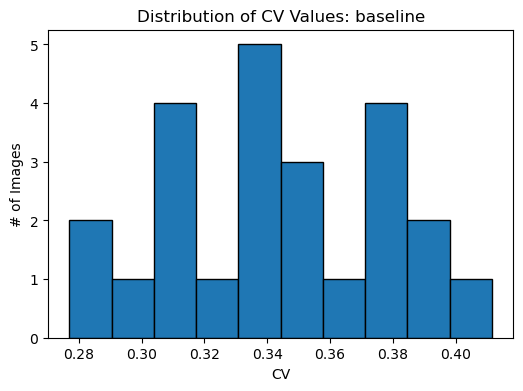

In [26]:
import os
import zipfile
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# USER INPUTS
# =========================
zip_path = "baseline3.zip"
extract_folder = "baseline3_extracted"
folder_path = extract_folder
geometry_name = "baseline"

# ROI settings
x1_frac = 0.15
x2_frac = 0.80
y1_frac = 0.15
y2_frac = 0.55

valid_ext = (".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff")

# =========================
# UNZIP IMAGES
# =========================
if not os.path.exists(extract_folder):
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(extract_folder)
    print("Images unzipped.")
else:
    print("Folder already exists. Skipping unzip.")

# =========================
# GET IMAGE FILES
# =========================
files = sorted([
    f for f in os.listdir(folder_path)
    if f.lower().endswith(valid_ext)
])

if len(files) == 0:
    raise ValueError("No image files found in folder.")

print(f"Found {len(files)} images.")

# =========================
# PROCESS EACH IMAGE
# =========================
results = []

for fname in files:
    path = os.path.join(folder_path, fname)

    img = cv2.imread(path)
    if img is None:
        print(f"Skipping unreadable file: {fname}")
        continue

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    h, w = gray.shape

    x1 = int(x1_frac * w)
    x2 = int(x2_frac * w)
    y1 = int(y1_frac * h)
    y2 = int(y2_frac * h)

    roi = gray[y1:y2, x1:x2]

    if roi.size == 0:
        print(f"Skipping empty ROI for: {fname}")
        continue

    mean_intensity = np.mean(roi)
    std_intensity = np.std(roi)
    cv_value = std_intensity / mean_intensity if mean_intensity != 0 else np.nan

    results.append({
        "Geometry": geometry_name,
        "Image": fname,
        "Mean Intensity": mean_intensity,
        "Std Dev": std_intensity,
        "CV": cv_value,
        "x1": x1,
        "x2": x2,
        "y1": y1,
        "y2": y2
    })

# =========================
# SAVE + DISPLAY RESULTS
# =========================
df = pd.DataFrame(results)

if df.empty:
    raise ValueError("No valid results were generated.")

display(df)

output_csv = f"{geometry_name.lower().replace(' ', '_')}_mixing_results.csv"
df.to_csv(output_csv, index=False)

print(f"\nSaved results to: {output_csv}")
print("\nSummary:")
print(df[["Mean Intensity", "Std Dev", "CV"]].describe())

print(f"\nAverage CV for {geometry_name}: {df['CV'].mean():.3f}")
print(f"Best CV: {df['CV'].min():.3f}")
print(f"Worst CV: {df['CV'].max():.3f}")

# =========================
# SHOW ROI OVERLAYS FOR FIRST 5 IMAGES
# =========================
for fname in files[:5]:
    path = os.path.join(folder_path, fname)

    img = cv2.imread(path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    h, w = gray.shape

    x1 = int(x1_frac * w)
    x2 = int(x2_frac * w)
    y1 = int(y1_frac * h)
    y2 = int(y2_frac * h)

    roi = gray[y1:y2, x1:x2]

    img_overlay = img_rgb.copy()
    cv2.rectangle(img_overlay, (x1, y1), (x2, y2), (255, 0, 0), 4)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(img_overlay)
    plt.title(f"ROI Overlay: {fname}")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(roi, cmap="gray", aspect="auto")
    plt.title("Cropped ROI")
    plt.colorbar(label="Intensity")

    plt.tight_layout()
    plt.show()

# =========================
# CV HISTOGRAM
# =========================
plt.figure(figsize=(6, 4))
plt.hist(df["CV"], bins=10, edgecolor="black")
plt.title(f"Distribution of CV Values: {geometry_name}")
plt.xlabel("CV")
plt.ylabel("# of Images")
plt.show()

,Geometry,Image,Mean Intensity,Std Dev,CV
0,corkscrew,ezgif-frame-001.jpg,46.411704,10.703024,0.230610
1,corkscrew,ezgif-frame-002.jpg,46.678417,10.614144,0.227389
2,corkscrew,ezgif-frame-003.jpg,46.801145,10.668359,0.227951
3,corkscrew,ezgif-frame-004.jpg,46.809972,10.626497,0.227014
4,corkscrew,ezgif-frame-005.jpg,46.829081,10.629982,0.226995
...,...,...,...,...,...
170,corkscrew,ezgif-frame-171.jpg,38.921382,9.350749,0.240247
171,corkscrew,ezgif-frame-172.jpg,38.921055,9.352238,0.240287
172,corkscrew,ezgif-frame-173.jpg,38.989298,9.354951,0.239936
173,corkscrew,ezgif-frame-174.jpg,38.882980,9.359700,0.240715



Saved results to: corkscrew_mixing_results.csv

Summary:
       Mean Intensity     Std Dev          CV
count      175.000000  175.000000  175.000000
mean        42.980456   10.142500    0.236302
std          2.932949    0.492290    0.005190
min         38.882980    9.348157    0.224321
25%         40.605718    9.699627    0.232781
50%         41.640705    9.932205    0.238450
75%         45.980414   10.628306    0.240312
max         47.731739   10.872775    0.243553

Average CV for corkscrew: 0.236
Best (lowest) CV: 0.224
Worst (highest) CV: 0.244


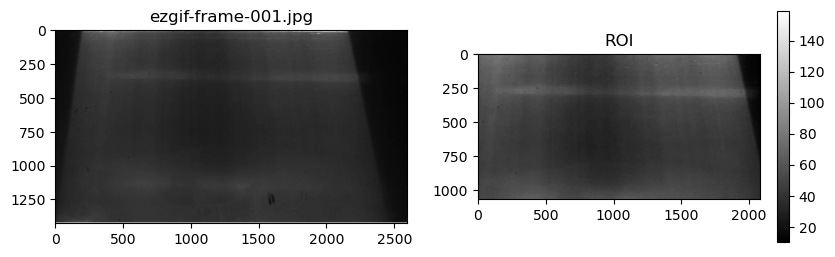

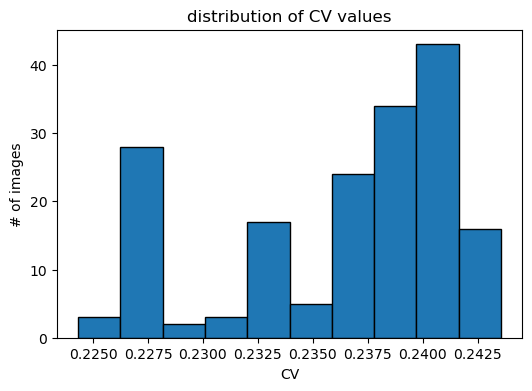

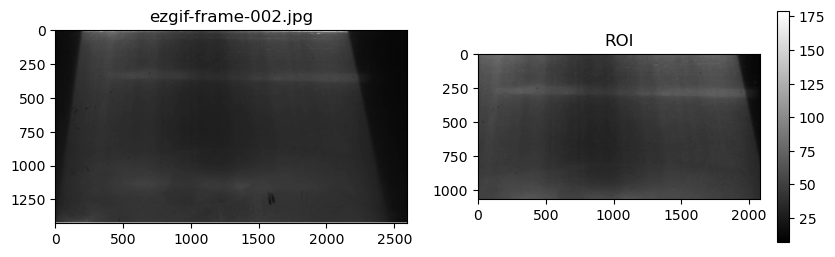

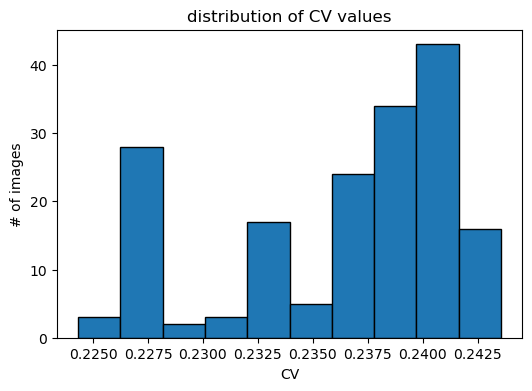

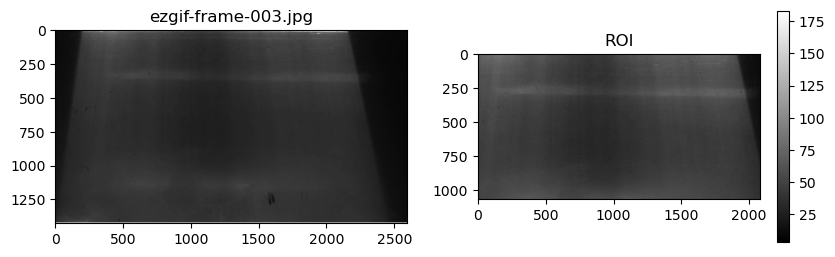

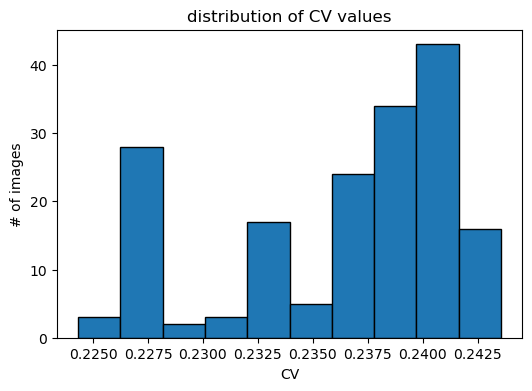

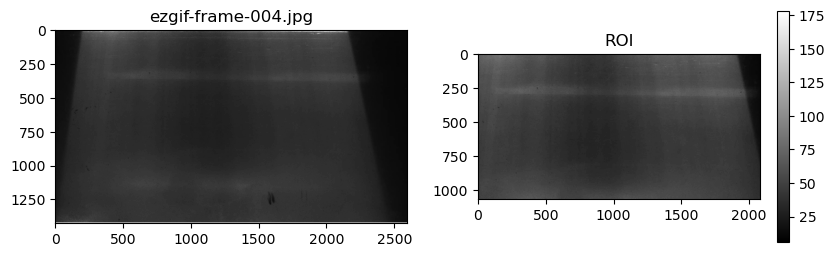

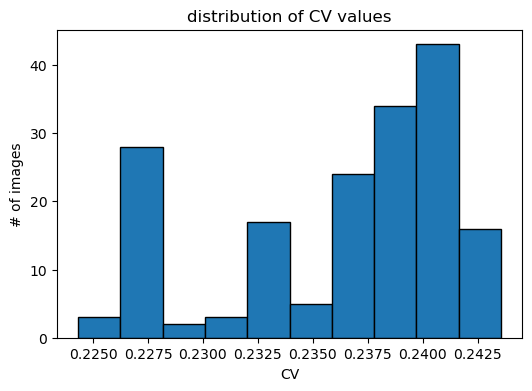

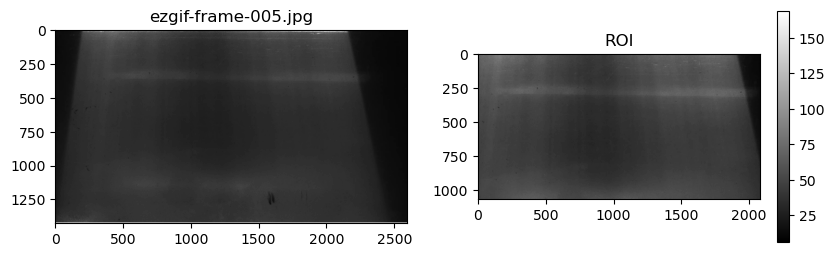

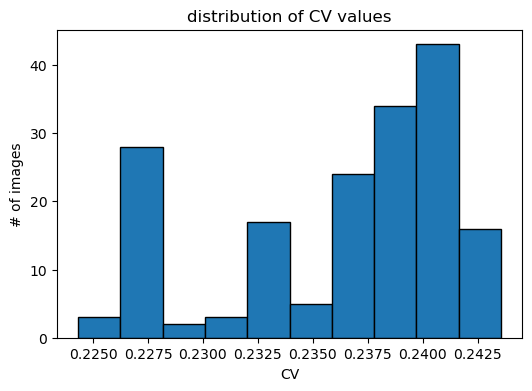

In [52]:

folder_path = "corkscrew_images"

import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# USER INPUTS
# =========================

geometry_name = "corkscrew"

# ROI settings: common comparison ROI
x1_frac = 0.10
x2_frac = 0.90

y1_frac = 0.05
y2_frac = 0.80

# valid image extensions
valid_ext = (".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff")
files = sorted([f for f in os.listdir(folder_path) if f.lower().endswith(valid_ext)])

if len(files) == 0:
    raise ValueError("No image files found in folder.")

results = []

# =========================
# PROCESS EACH IMAGE
# =========================
for fname in files:
    path = os.path.join(folder_path, fname)

    img = cv2.imread(path)
    if img is None:
        print(f"Skipping unreadable file: {fname}")
        continue

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

    h, w = gray.shape

    x1 = int(x1_frac * w)
    x2 = int(x2_frac * w)
    y1 = int(y1_frac * h)
    y2 = int(y2_frac * h)

    roi = gray[y1:y2, x1:x2]

    if roi.size == 0:
        print(f"Skipping empty ROI for: {fname}")
        continue

    mean_intensity = np.mean(roi)
    std_intensity = np.std(roi)
    cv = std_intensity / mean_intensity if mean_intensity != 0 else np.nan

    results.append({
        "Geometry": geometry_name,
        "Image": fname,
        "Mean Intensity": mean_intensity,
        "Std Dev": std_intensity,
        "CV": cv
    })

# =========================
# SAVE + DISPLAY RESULTS
# =========================
df = pd.DataFrame(results)

if df.empty:
    raise ValueError("No valid results were generated.")

display(df)

output_csv = f"{geometry_name.lower().replace(' ', '_')}_mixing_results.csv"
df.to_csv(output_csv, index=False)

print(f"\nSaved results to: {output_csv}")
print("\nSummary:")
print(df[["Mean Intensity", "Std Dev", "CV"]].describe())

print(f"\nAverage CV for {geometry_name}: {df['CV'].mean():.3f}")
print(f"Best (lowest) CV: {df['CV'].min():.3f}")
print(f"Worst (highest) CV: {df['CV'].max():.3f}")
for fname in files[:5]:
    path = os.path.join(folder_path, fname)
    img = cv2.imread(path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    h, w = gray.shape
    x1 = int(x1_frac * w)
    x2 = int(x2_frac * w)
    y1 = int(y1_frac * h)
    y2 = int(y2_frac * h)

    roi = gray[y1:y2, x1:x2]

    plt.figure(figsize=(10,3))
    plt.subplot(1,2,1)
    plt.imshow(gray, cmap="gray")
    plt.title(fname)
    plt.subplot(1,2,2)
    plt.imshow(roi, cmap="gray")
    plt.title("ROI")
    plt.colorbar()
    plt.show()
    plt.figure(figsize=(6,4))
    plt.hist(df["CV"], bins=10, edgecolor='black')
    plt.title("distribution of CV values")
    plt.xlabel("CV")
    plt.ylabel("# of images")
    plt.show()

,Geometry,Image,Mean Intensity,Std Dev,CV
0,triple coil helix,ezgif-frame-001.jpg,122.114697,21.959266,0.179825
1,triple coil helix,ezgif-frame-002.jpg,125.478625,23.107134,0.184152
2,triple coil helix,ezgif-frame-003.jpg,125.479555,23.201389,0.184902
3,triple coil helix,ezgif-frame-004.jpg,126.783114,21.510144,0.169661
4,triple coil helix,ezgif-frame-005.jpg,126.712831,21.640152,0.170781
5,triple coil helix,ezgif-frame-006.jpg,134.041210,22.742466,0.169668
6,triple coil helix,ezgif-frame-007.jpg,122.987098,19.517231,0.158693
7,triple coil helix,ezgif-frame-008.jpg,119.596665,20.353610,0.170185
8,triple coil helix,ezgif-frame-009.jpg,121.155011,20.837113,0.171987
9,triple coil helix,ezgif-frame-010.jpg,108.979576,22.287227,0.204508



Saved results to: triple_coil_helix_mixing_results.csv

Summary:
       Mean Intensity    Std Dev         CV
count       59.000000  59.000000  59.000000
mean        85.824996  15.618018   0.183047
std         21.216147   3.517748   0.009352
min         63.545934  12.052322   0.158693
25%         67.469231  13.161722   0.178121
50%         74.538235  13.384790   0.183249
75%         98.005371  18.108313   0.186952
max        134.041210  23.201389   0.204508

Average CV for triple coil helix: 0.183
Best (lowest) CV: 0.159
Worst (highest) CV: 0.205


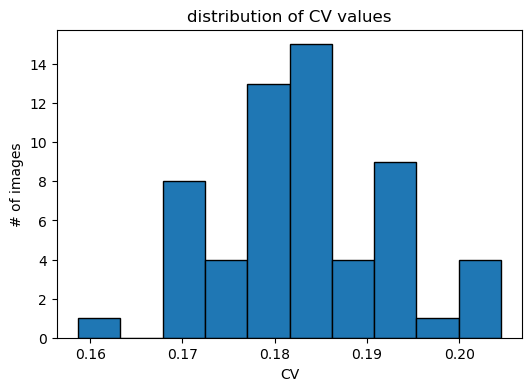

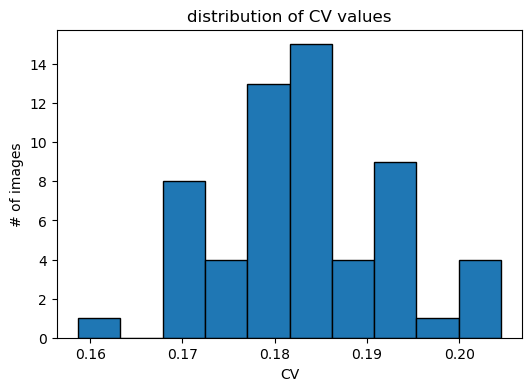

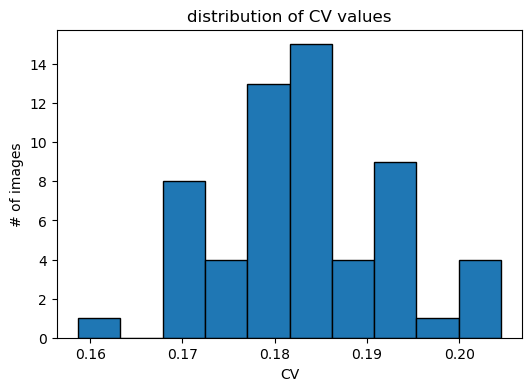

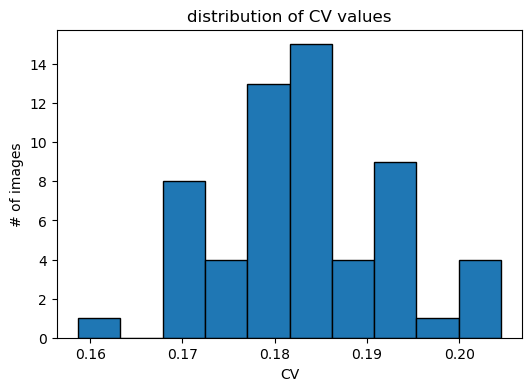

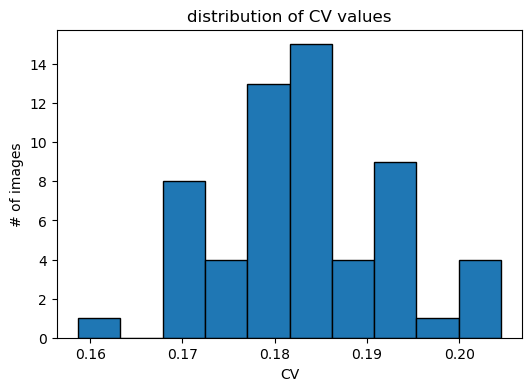

In [44]:
import zipfile

zip_path = "ezgif-4da48a0cd1922b98-jpg.zip"
extract_folder = "triplecoil_images"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_folder)


folder_path = "triplecoil_images"

import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# USER INPUTS
# =========================

geometry_name = "triple coil helix"

# ROI settings: common comparison ROI
x1_frac = 0.10
x2_frac = 0.90

y1_frac = 0.05
y2_frac = 0.80

# valid image extensions
valid_ext = (".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff")
files = sorted([f for f in os.listdir(folder_path) if f.lower().endswith(valid_ext)])

if len(files) == 0:
    raise ValueError("No image files found in folder.")

results = []

# =========================
# PROCESS EACH IMAGE
# =========================
for fname in files:
    path = os.path.join(folder_path, fname)

    img = cv2.imread(path)
    if img is None:
        print(f"Skipping unreadable file: {fname}")
        continue

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

    h, w = gray.shape

    x1 = int(x1_frac * w)
    x2 = int(x2_frac * w)
    y1 = int(y1_frac * h)
    y2 = int(y2_frac * h)

    roi = gray[y1:y2, x1:x2]

    if roi.size == 0:
        print(f"Skipping empty ROI for: {fname}")
        continue

    mean_intensity = np.mean(roi)
    std_intensity = np.std(roi)
    cv = std_intensity / mean_intensity if mean_intensity != 0 else np.nan

    results.append({
        "Geometry": geometry_name,
        "Image": fname,
        "Mean Intensity": mean_intensity,
        "Std Dev": std_intensity,
        "CV": cv
    })

# =========================
# SAVE + DISPLAY RESULTS
# =========================
df = pd.DataFrame(results)

if df.empty:
    raise ValueError("No valid results were generated.")

display(df)

output_csv = f"{geometry_name.lower().replace(' ', '_')}_mixing_results.csv"
df.to_csv(output_csv, index=False)

print(f"\nSaved results to: {output_csv}")
print("\nSummary:")
print(df[["Mean Intensity", "Std Dev", "CV"]].describe())

print(f"\nAverage CV for {geometry_name}: {df['CV'].mean():.3f}")
print(f"Best (lowest) CV: {df['CV'].min():.3f}")
print(f"Worst (highest) CV: {df['CV'].max():.3f}")
for fname in files[:5]:
    path = os.path.join(folder_path, fname)
    img = cv2.imread(path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    h, w = gray.shape
    x1 = int(x1_frac * w)
    x2 = int(x2_frac * w)
    y1 = int(y1_frac * h)
    y2 = int(y2_frac * h)

    roi = gray[y1:y2, x1:x2]

   # plt.figure(figsize=(10,3))
   # plt.subplot(1,2,1)
  #  plt.imshow(gray, cmap="gray")
  #  plt.title(fname)

  #  plt.subplot(1,2,2)
 #   plt.imshow(roi, cmap="gray")
 #   plt.title("ROI")
  #  plt.colorbar()
  #  plt.show()
    plt.figure(figsize=(6,4))
    plt.hist(df["CV"], bins=10, edgecolor='black')
    plt.title("distribution of CV values")
    plt.xlabel("CV")
    plt.ylabel("# of images")
    plt.show()


Processing geometry: baseline
Folder already exists for: baseline2.zip
baseline2.zip: Found 19 images
Folder already exists for: baseline3.zip
baseline3.zip: Found 24 images
Folder already exists for: baseline5.zip
baseline5.zip: Found 56 images

Saved baseline results to: mixing_results_output/baseline_mixing_results.csv
Average CV for baseline: 0.321
Best CV for baseline: 0.239
Worst CV for baseline: 0.412

Processing geometry: pachinko
Folder already exists for: pachinko1.zip
pachinko1.zip: Found 96 images
Folder already exists for: pachinko3.zip
pachinko3.zip: Found 93 images

Saved pachinko results to: mixing_results_output/pachinko_mixing_results.csv
Average CV for pachinko: 0.357
Best CV for pachinko: 0.275
Worst CV for pachinko: 0.561

Processing geometry: triple coil
Folder already exists for: triplecoil1.zip
triplecoil1.zip: Found 100 images
Folder already exists for: triplecoil2.zip
triplecoil2.zip: Found 55 images

Saved triple coil results to: mixing_results_output/triple

,Geometry,Zip Source,Image,Mean Intensity,Std Dev,CV,x1,x2,y1,y2
0,baseline,baseline2.zip,ezgif-frame-001.jpg,46.969875,17.321606,0.368781,260,1388,196,719
1,baseline,baseline2.zip,ezgif-frame-002.jpg,46.969104,17.442263,0.371356,260,1388,196,719
2,baseline,baseline2.zip,ezgif-frame-003.jpg,68.275367,22.073994,0.323308,260,1388,196,719
3,baseline,baseline2.zip,ezgif-frame-004.jpg,68.346640,21.975433,0.321529,260,1388,196,719
4,baseline,baseline2.zip,ezgif-frame-005.jpg,73.776558,21.006003,0.284725,260,1388,196,719
...,...,...,...,...,...,...,...,...,...,...
438,triple coil,triplecoil2.zip,ezgif-frame-051.jpg,25.741532,8.956680,0.347947,259,1384,196,720
439,triple coil,triplecoil2.zip,ezgif-frame-052.jpg,25.741532,8.956680,0.347947,259,1384,196,720
440,triple coil,triplecoil2.zip,ezgif-frame-053.jpg,25.741532,8.956680,0.347947,259,1384,196,720
441,triple coil,triplecoil2.zip,ezgif-frame-054.jpg,25.741532,8.956680,0.347947,259,1384,196,720



Saved combined results to: mixing_results_output/all_geometries_mixing_results.csv


,Geometry,Count,Mean_CV,Std_CV,Best_CV,Worst_CV
0,baseline,99,0.321393,0.031916,0.239250,0.411506
1,pachinko,189,0.357357,0.076690,0.275466,0.560961
2,triple coil,155,0.316143,0.021618,0.243994,0.353714


Saved summary to: mixing_results_output/summary_by_geometry.csv


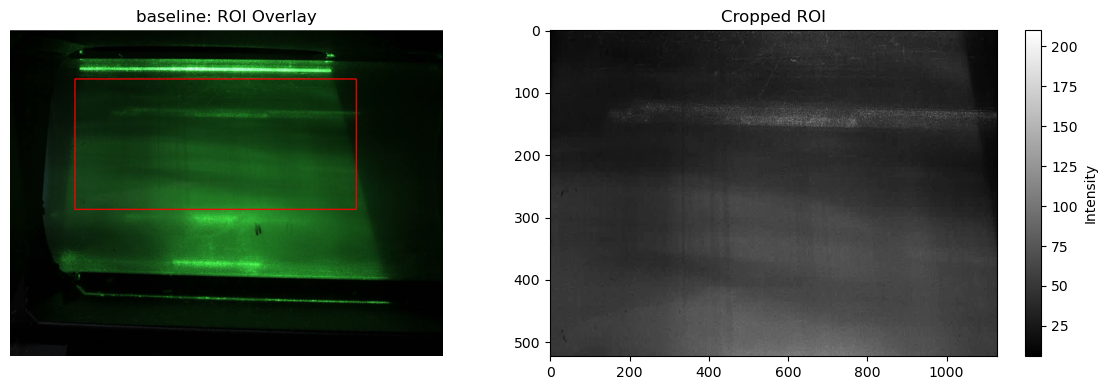

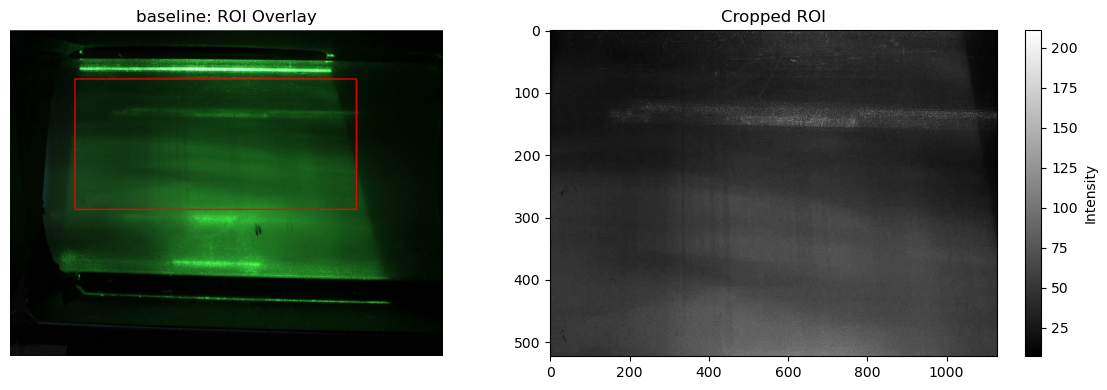

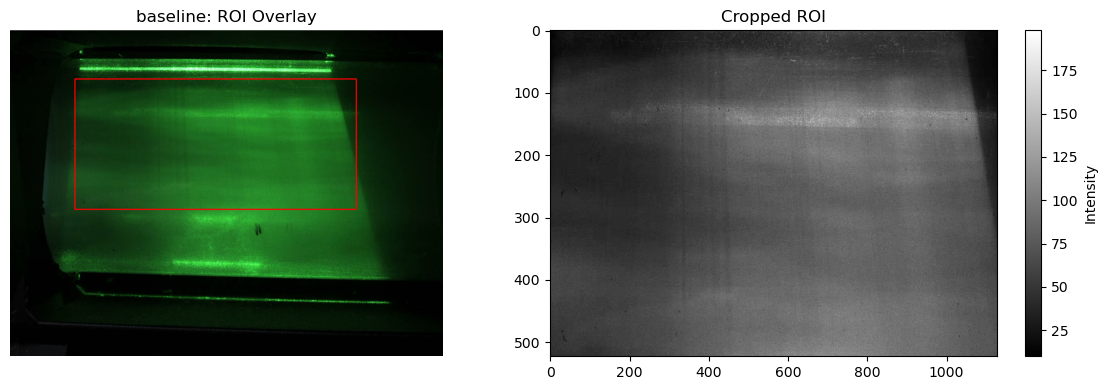

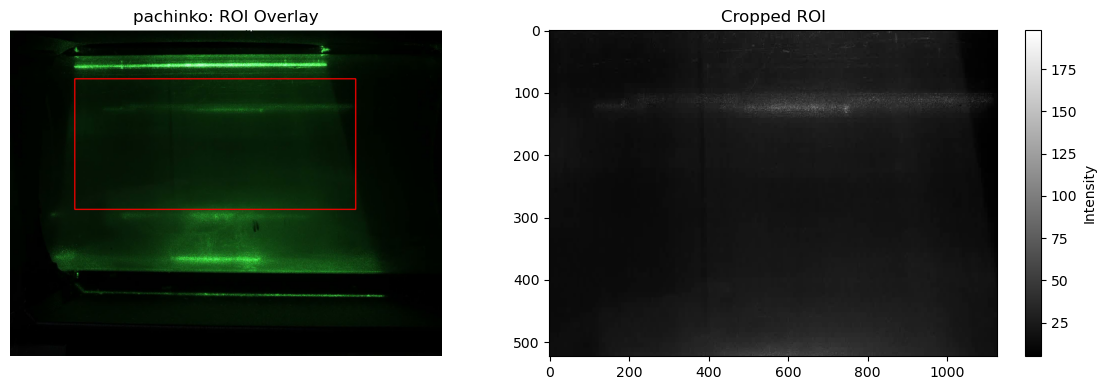

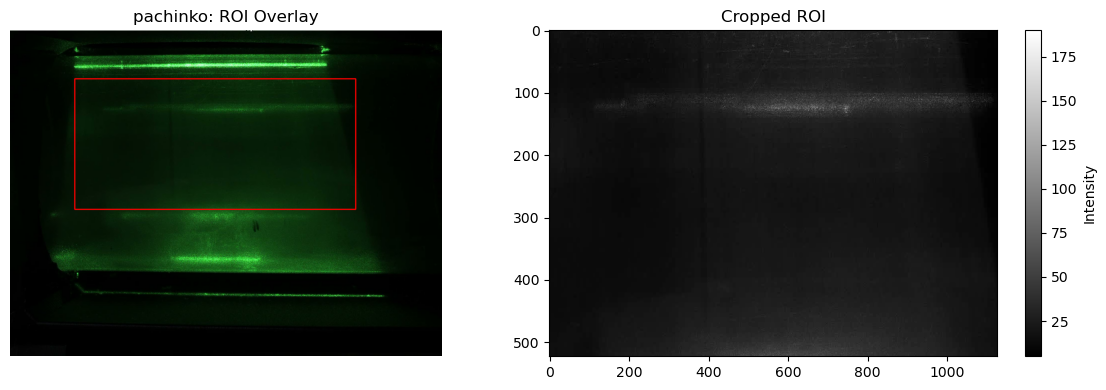

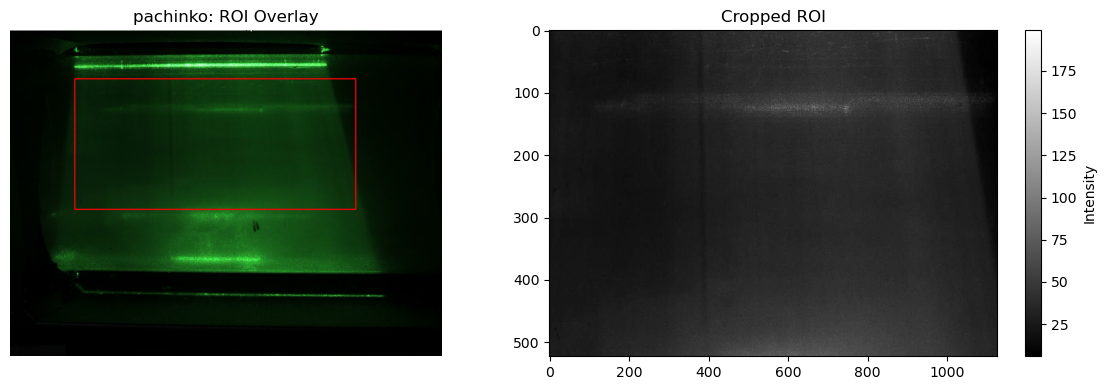

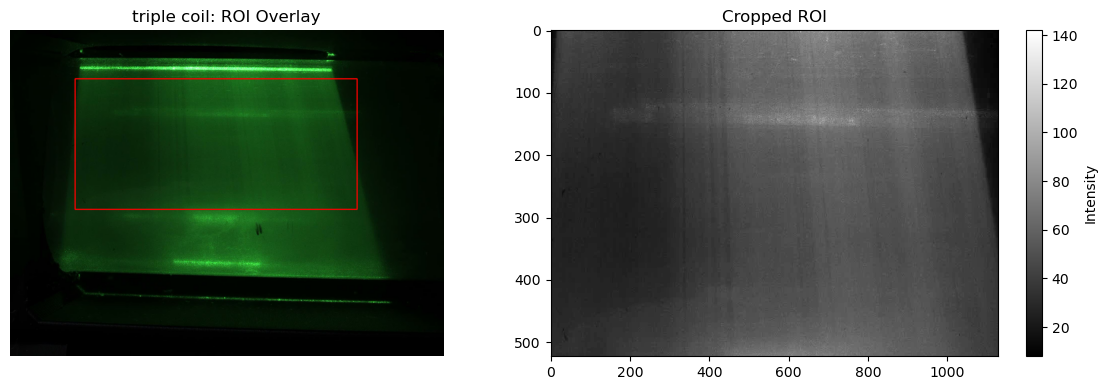

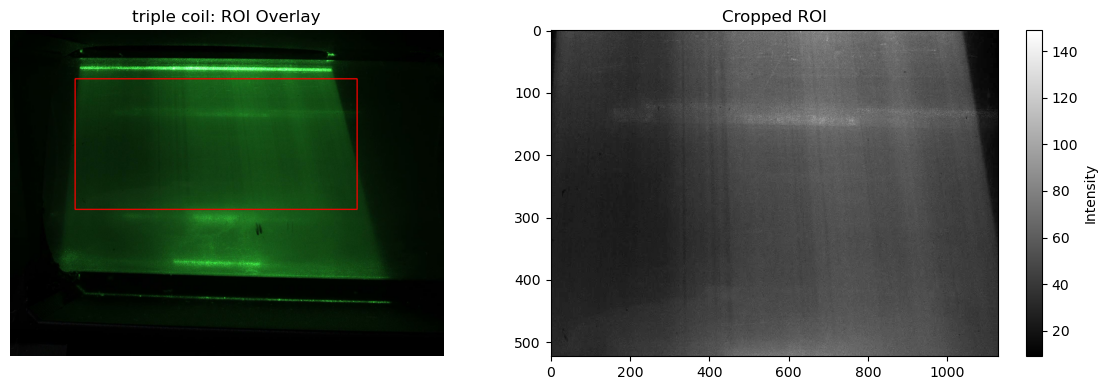

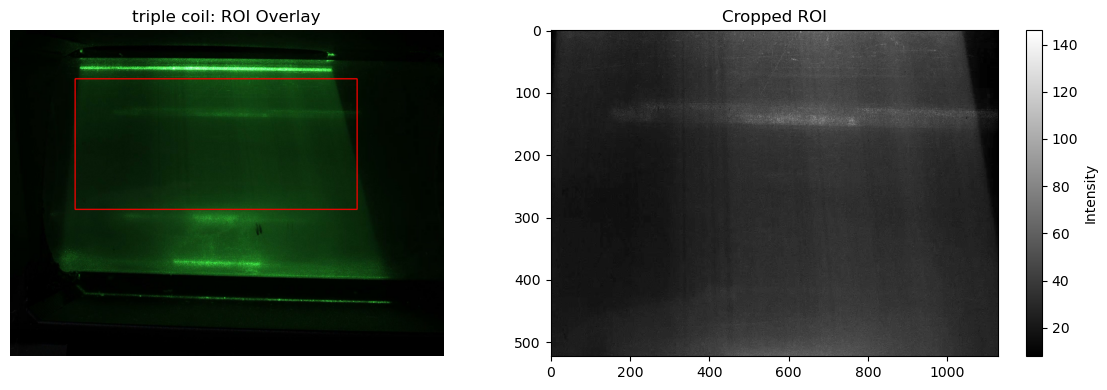

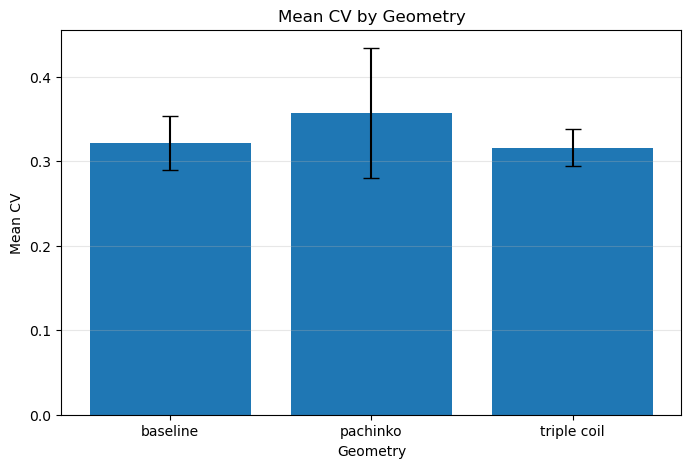

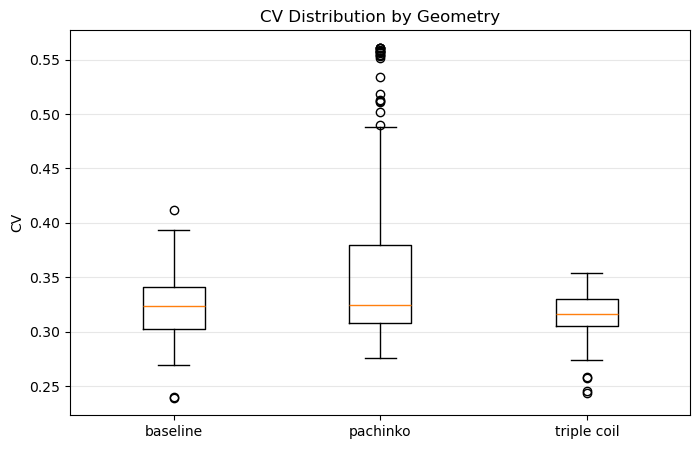

baseline:
       Mean Intensity    Std Dev         CV
count       99.000000  99.000000  99.000000
mean        31.529484  10.006328   0.321393
std         14.438495   4.177225   0.031916
min         18.227407   6.038995   0.239250
25%         22.652770   7.084616   0.302163
50%         25.429107   8.096373   0.323612
75%         34.019861  11.436402   0.340776
max         81.028092  24.582186   0.411506

Average CV for baseline: 0.321
Best (lowest) CV: 0.239
Worst (highest) CV: 0.412
Number of images: 99


In [3]:
import os
import zipfile
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# USER INPUTS
# =========================
# dumped in all my zip files of images 
GEOMETRIES = [
    ("baseline", ["baseline2.zip", "baseline3.zip", "baseline5.zip"]),
    ("pachinko", ["pachinko1.zip", "pachinko3.zip"]),
    ("triple coil", ["triplecoil1.zip", "triplecoil2.zip"]),
]
# center ROI, consistent
# ROI settings
x1_frac = 0.15
x2_frac = 0.80
y1_frac = 0.15
y2_frac = 0.55

valid_ext = (".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff")
# Saving into new folder
output_folder = "mixing_results_output"
os.makedirs(output_folder, exist_ok=True)

# =========================
# In  case we need to unzip our files, put into folder
# =========================

def unzip_if_needed(zip_path):
    extract_folder = zip_path.replace(".zip", "_extracted")

    if not os.path.exists(extract_folder):
        with zipfile.ZipFile(zip_path, "r") as zip_ref:
            zip_ref.extractall(extract_folder)
        print(f"Unzipped: {zip_path}")
    else:
        print(f"Folder already exists for: {zip_path}")

    return extract_folder


def get_image_files(folder_path):
    return sorted([
        f for f in os.listdir(folder_path)
        if f.lower().endswith(valid_ext)
    ])

# grayscale computations
def compute_roi(gray):
    h, w = gray.shape

    x1 = int(x1_frac * w)
    x2 = int(x2_frac * w)
    y1 = int(y1_frac * h)
    y2 = int(y2_frac * h)

    roi = gray[y1:y2, x1:x2]

    return roi, x1, x2, y1, y2

# all calcs we want from the test
def compute_cv(roi):
    mean_intensity = np.mean(roi)
    std_intensity = np.std(roi)
    cv_value = std_intensity / mean_intensity if mean_intensity != 0 else np.nan

    return mean_intensity, std_intensity, cv_value


# =========================
# PROCESS ALL GEOMETRIES
# =========================

all_results = []

for geometry_name, zip_files in GEOMETRIES:
    print("\n" + "=" * 60)
    print(f"Processing geometry: {geometry_name}")
    print("=" * 60)

    geometry_results = []

    for zip_path in zip_files:
        folder_path = unzip_if_needed(zip_path)
        files = get_image_files(folder_path)

        if len(files) == 0:
            print(f"No image files found in {folder_path}")
            continue

        print(f"{zip_path}: Found {len(files)} images")

        for fname in files:
            path = os.path.join(folder_path, fname)

            img = cv2.imread(path)
            if img is None:
                print(f"Skipping unreadable file: {fname}")
                continue

            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

            roi, x1, x2, y1, y2 = compute_roi(gray)

            if roi.size == 0:
                print(f"Skipping empty ROI for: {fname}")
                continue

            mean_intensity, std_intensity, cv_value = compute_cv(roi)

            row = {
                "Geometry": geometry_name,
                "Zip Source": zip_path,
                "Image": fname,
                "Mean Intensity": mean_intensity,
                "Std Dev": std_intensity,
                "CV": cv_value,
                "x1": x1,
                "x2": x2,
                "y1": y1,
                "y2": y2
            }

            geometry_results.append(row)
            all_results.append(row)

    # Save per-geometry CSV
    if geometry_results:
        df_geometry = pd.DataFrame(geometry_results)

        safe_name = geometry_name.lower().replace(" ", "_")
        output_csv = os.path.join(output_folder, f"{safe_name}_mixing_results.csv")
        df_geometry.to_csv(output_csv, index=False)

        print(f"\nSaved {geometry_name} results to: {output_csv}")
        print(f"Average CV for {geometry_name}: {df_geometry['CV'].mean():.3f}")
        print(f"Best CV for {geometry_name}: {df_geometry['CV'].min():.3f}")
        print(f"Worst CV for {geometry_name}: {df_geometry['CV'].max():.3f}")


# =========================
# COMBINED RESULTS
# =========================

df_all = pd.DataFrame(all_results)

if df_all.empty:
    raise ValueError("No valid results were generated.")

display(df_all)

combined_csv = os.path.join(output_folder, "all_geometries_mixing_results.csv")
df_all.to_csv(combined_csv, index=False)

print(f"\nSaved combined results to: {combined_csv}")

# =========================
# SUMMARY TABLE
# =========================

summary = df_all.groupby("Geometry")["CV"].agg(
    Count="count",
    Mean_CV="mean",
    Std_CV="std",
    Best_CV="min",
    Worst_CV="max"
).reset_index()

display(summary)

summary_csv = os.path.join(output_folder, "summary_by_geometry.csv")
summary.to_csv(summary_csv, index=False)

print(f"Saved summary to: {summary_csv}")

# =========================
# ROI overlays, ensure ROI is valid
# =========================

for geometry_name, zip_files in GEOMETRIES:
    shown = 0

    for zip_path in zip_files:
        folder_path = zip_path.replace(".zip", "_extracted")
        files = get_image_files(folder_path)

        for fname in files:
            if shown >= 3:
                break

            path = os.path.join(folder_path, fname)

            img = cv2.imread(path)
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

            roi, x1, x2, y1, y2 = compute_roi(gray)

            img_overlay = img_rgb.copy()
            cv2.rectangle(img_overlay, (x1, y1), (x2, y2), (255, 0, 0), 4)

            plt.figure(figsize=(12, 4))

            plt.subplot(1, 2, 1)
            plt.imshow(img_overlay)
            plt.title(f"{geometry_name}: ROI Overlay")
            plt.axis("off")

            plt.subplot(1, 2, 2)
            plt.imshow(roi, cmap="gray", aspect="auto")
            plt.title("Cropped ROI")
            plt.colorbar(label="Intensity")

            plt.tight_layout()
            plt.show()

            shown += 1

        if shown >= 3:
            break

# =========================
# HISTOGRAM: CV DISTRIBUTION BY GEOMETRY
# =========================

plt.figure(figsize=(8, 5))

for geometry_name in df_all["Geometry"].unique():
    vals = df_all[df_all["Geometry"] == geometry_name]["CV"]
    plt.hist(vals, bins=10, alpha=0.5, label=geometry_name)

plt.title("Distribution of CV Values by Geometry")
plt.xlabel("CV")
plt.ylabel("# of Images")
plt.legend()
plt.show()


plt.show()
geometry_to_show = "baseline"

df_geo = df_all[df_all["Geometry"] == geometry_to_show]

print(f"{geometry_to_show}:")
print(df_geo[["Mean Intensity", "Std Dev", "CV"]].describe())

print(f"\nAverage CV for {geometry_to_show}: {df_geo['CV'].mean():.3f}")
print(f"Best (lowest) CV: {df_geo['CV'].min():.3f}")
print(f"Worst (highest) CV: {df_geo['CV'].max():.3f}")
print(f"Number of images: {len(df_geo)}")